# Fine-Tuning de Modelos en Azure AI Foundry

En esta práctica aplicarás los conocimientos sobre fine-tuning de modelos de lenguaje en Azure AI Foundry. Entrenarás un modelo personalizado utilizando tu propio dataset y evaluarás su rendimiento comparándolo con el modelo base.

Podrás elegir entre dos modalidades de implementación:
- **Modalidad Portal**: Realizar el fine-tuning desde Azure AI Foundry Studio (requiere video del proceso)
- **Modalidad Python SDK**: Implementar el fine-tuning programáticamente usando código Python

La práctica se divide en una única parte integral y el entregable final será un **Jupyter Notebook** que documente todo el proceso y demuestre el funcionamiento del modelo fine-tuned.

---

## Parte 1) Entrenamiento y Evaluación de Modelo Fine-Tuned
**Objetivo:** Entrenar un modelo de lenguaje personalizado mediante fine-tuning, desplegarlo y evaluar su rendimiento mediante pruebas comparativas y análisis de métricas.



### 1.1 - Preparación del Dataset de Fine-Tuning

Crea o selecciona un dataset personalizado que defina el comportamiento deseado para tu modelo fine-tuned.

**Requisitos del dataset:**
- Formato **JSONL** (JSON Lines) compatible con Chat Completions API
- Mínimo **50-100 ejemplos** de conversaciones (recomendado: 100-300 para mejores resultados)
- Estructura conversacional con roles: `system`, `user`, `assistant`
- División en dos archivos:
  - `training_set.jsonl` (80% de los datos)
  - `validation_set.jsonl` (20% de los datos)

**Ejemplos de casos de uso:**
- Chatbot de soporte técnico especializado en un tema específico
- Asistente que responde con un tono/estilo particular (formal, casual, sarcástico, etc.)
- Generador de contenido en formato específico (JSON, XML, markdown estructurado)
- Asistente de código especializado en un lenguaje o framework
- Sistema de respuestas basado en documentación interna

**Documentación:**
- [Preparación de datos para fine-tuning](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning?pivots=programming-language-python#prepare-your-training-and-validation-data)
- [Formato de archivo JSONL para Chat Completions](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning?pivots=programming-language-python#example-file-format)

---

1. Training: training_set.jsonl
2. Validacion: validation_set.jsonl

In [16]:
from pathlib import Path

# Carga directa desde el archivo .env en la carpeta del proyecto
project_env_path = Path.cwd().parent / ".env"

if not project_env_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {project_env_path}")

ENV = {}
for raw_line in project_env_path.read_text(encoding="utf-8-sig").splitlines():
    line = raw_line.strip()
    if not line or line.startswith("#") or "=" not in line:
        continue

    if line.lower().startswith("export "):
        line = line[7:].strip()

    key, value = line.split("=", 1)
    key = key.strip()
    value = value.strip().strip('"').strip("'")

    if " #" in value:
        value = value.split(" #", 1)[0].strip()

    ENV[key] = value

print(f".env cargado desde: {project_env_path}")
print("Claves encontradas:", ", ".join(sorted(ENV.keys())))

.env cargado desde: c:\Users\Alumno_AI\Desktop\practicasIAGenerativa\.env
Claves encontradas: AZURE_FOUNDRY_MODELS_ENDPOINT, AZURE_FOUNDRY_OPENAI_BASE_URL, AZURE_FOUNDRY_PROJECT_ENDPOINT, AZURE_OPENAI_CHAT_DEPLOYMENT, AZURE_OPENAI_REASONING_DEPLOYMENT, AZURE_PHI_MULTIMODAL_DEPLOYMENT, DEFAULT_IMAGE_URL


### 1.2 - Entrenamiento del Modelo (elegir una modalidad)

Realiza el fine-tuning de un modelo de Azure OpenAI usando el dataset preparado. **Elige UNA de las dos modalidades:**

#### 🖥️ Opción A - Modalidad Portal (Azure AI Foundry Studio)

Si eliges esta modalidad:
- Accede a [Azure AI Foundry](https://ai.azure.com/)
- Navega a la sección **Fine-tuning** y crea un nuevo trabajo
- Configura:
  - **Modelo base**: GPT-4o-mini, GPT-4o, u otro disponible
  - **Training type**: Standard, Global o Developer (justifica tu elección)
  - **Hiperparámetros**: Puedes usar valores automáticos o ajustarlos manualmente
  - **Suffix**: Nombre descriptivo para tu modelo (ej: "soporte-azure-v1")
- Sube los archivos `training_set.jsonl` y `validation_set.jsonl`
- Monitorea el progreso del entrenamiento

**📹 Requisito adicional para esta modalidad:**
- Graba un **video** mostrando la configuración del trabajo de fine-tuning
- Sube el video a SharePoint y proporciona el enlace en el notebook

**Documentación:**
- [Fine-tuning desde Azure AI Foundry Studio](https://learn.microsoft.com/es-es/azure/foundry/openai/how-to/fine-tuning?tabs=turbo%2Cpython-secure&pivots=programming-language-studio)

#### 💻 Opción B - Modalidad Python SDK

Si eliges esta modalidad, implementa el proceso completo usando código:

```python
from openai import AzureOpenAI
import os

# 1. Configurar cliente
client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version="2024-05-01-preview",
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT")
)

# 2. Subir archivos de entrenamiento
# 3. Crear trabajo de fine-tuning
# 4. Monitorear estado y métricas
```

**Requisitos de implementación:**
- Código para subir archivos de training y validation
- Creación del trabajo de fine-tuning con configuración personalizada
- Función para monitorear el estado del job (`queued`, `running`, `succeeded`)
- Captura y visualización de métricas de entrenamiento
- Manejo de errores y validaciones

**Documentación:**
- [Fine-tuning con Python SDK](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning?pivots=programming-language-python)
- [Azure OpenAI Python SDK Reference](https://learn.microsoft.com/es-es/python/api/overview/azure/ai-openai-readme?view=azure-python-preview)

---

In [18]:
from openai import OpenAI
from azure.identity import DefaultAzureCredential

# Leer configuracion exclusivamente desde el .env cargado en ENV
api_key = ENV.get("AZURE_OPENAI_API_KEY") or ENV.get("OPENAI_API_KEY")
base_url = ENV.get("AZURE_FOUNDRY_OPENAI_BASE_URL")

if not base_url:
    raise ValueError(
        "Falta AZURE_FOUNDRY_OPENAI_BASE_URL en el archivo .env del proyecto."
    )

# Si no hay API key en .env, usar Entra ID (Azure AD)
if not api_key:
    credential = DefaultAzureCredential()
    try:
        api_key = credential.get_token("https://ai.azure.com/.default").token
    except Exception:
        api_key = credential.get_token("https://cognitiveservices.azure.com/.default").token

client = OpenAI(
    api_key=api_key,
    base_url=base_url,
 )

# Modelo base recomendado en la práctica
MODEL_NAME = "gpt-4o-mini"

# Cargar archivos de entrenamiento y validación
training_file_name = "training_set.jsonl"
validation_file_name = "validation_set.jsonl"

with open(training_file_name, "rb") as train_file:
    training_response = client.files.create(
        file=train_file,
        purpose="fine-tune",
    )

with open(validation_file_name, "rb") as val_file:
    validation_response = client.files.create(
        file=val_file,
        purpose="fine-tune",
    )

training_file_id = training_response.id
validation_file_id = validation_response.id

print("Modelo base:", MODEL_NAME)
print("Training file ID:", training_file_id)
print("Validation file ID:", validation_file_id)

Modelo base: gpt-4o-mini
Training file ID: file-22dbdba5f58d4f5d81f6bf77e0031679
Validation file ID: file-02f4bbd1b84f479195f881ce702000a9


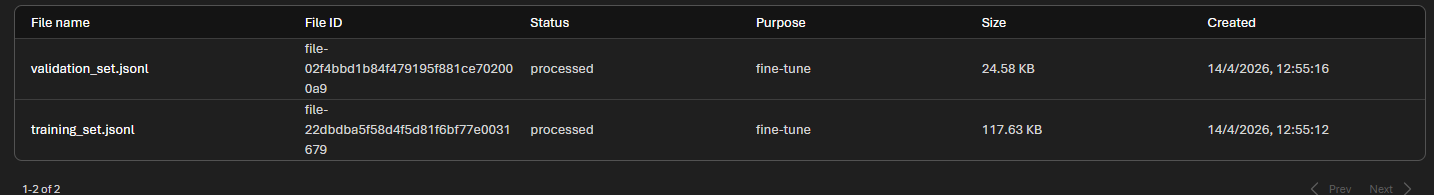

In [19]:
# Crear trabajo de fine-tuning (patrón oficial del SDK)
response = client.fine_tuning.jobs.create(
    training_file=training_file_id,
    validation_file=validation_file_id,
    model=MODEL_NAME,
    suffix="modelo-ojeador",
    seed=105,
    extra_body={"trainingType": "GlobalStandard"},
)

job_id = response.id
print("Job ID:", job_id)
print(response.model_dump_json(indent=2))

# Consultar estado del job
job_status = client.fine_tuning.jobs.retrieve(job_id)
print("Status:", job_status.status)

# Listar eventos recientes
events = client.fine_tuning.jobs.list_events(
    fine_tuning_job_id=job_id,
    limit=10,
)
print(events.model_dump_json(indent=2))

Job ID: ftjob-c2ed7f6bac78495c8a13c32469561a07
{
  "id": "ftjob-c2ed7f6bac78495c8a13c32469561a07",
  "created_at": 1776164524,
  "error": null,
  "fine_tuned_model": null,
  "finished_at": null,
  "hyperparameters": {
    "batch_size": -1,
    "learning_rate_multiplier": 1.0,
    "n_epochs": -1
  },
  "model": "gpt-4o-mini-2024-07-18",
  "object": "fine_tuning.job",
  "organization_id": null,
  "result_files": null,
  "seed": 105,
  "status": "pending",
  "trained_tokens": null,
  "training_file": "file-22dbdba5f58d4f5d81f6bf77e0031679",
  "validation_file": "file-02f4bbd1b84f479195f881ce702000a9",
  "estimated_finish": 1776165439,
  "integrations": null,
  "metadata": {
    "base_model": "gpt-4o-mini",
    "model_version": "2024-07-18"
  },
  "method": {
    "type": "supervised",
    "dpo": null,
    "reinforcement": null,
    "supervised": {
      "hyperparameters": {
        "batch_size": -1,
        "learning_rate_multiplier": 1.0,
        "n_epochs": -1
      }
    }
  },
  "suffi

In [22]:
# Analisis de metricas del fine-tuning (results.csv)
import csv
import io
from statistics import mean
from openai import OpenAI
from azure.identity import DefaultAzureCredential

# Renueva autenticacion para evitar 401 por token expirado
base_url_metrics = ENV.get("AZURE_FOUNDRY_OPENAI_BASE_URL")
api_key_metrics = ENV.get("AZURE_OPENAI_API_KEY") or ENV.get("OPENAI_API_KEY")

if not base_url_metrics:
    raise ValueError("Falta AZURE_FOUNDRY_OPENAI_BASE_URL en .env")

if not api_key_metrics:
    cred = DefaultAzureCredential()
    try:
        api_key_metrics = cred.get_token("https://ai.azure.com/.default").token
    except Exception:
        api_key_metrics = cred.get_token("https://cognitiveservices.azure.com/.default").token

metrics_client = OpenAI(api_key=api_key_metrics, base_url=base_url_metrics)

job_details = metrics_client.fine_tuning.jobs.retrieve(job_id)
print("Estado actual del job:", job_details.status)

if job_details.status != "succeeded":
    print("El entrenamiento aun no termina. Ejecuta esta celda cuando el estado sea 'succeeded'.")
else:
    if not job_details.result_files:
        raise ValueError("El job finalizo, pero no hay result_files para analizar.")

    result_file_id = job_details.result_files[0]
    result_file = metrics_client.files.retrieve(result_file_id)
    print("Archivo de resultados:", result_file.filename, "| ID:", result_file_id)

    raw_bytes = metrics_client.files.content(result_file_id).read()
    csv_text = raw_bytes.decode("utf-8-sig", errors="replace")
    reader = csv.DictReader(io.StringIO(csv_text))
    rows = list(reader)

    if not rows:
        raise ValueError("El archivo de resultados esta vacio.")

    def to_float(value):
        if value is None or value == "":
            return None
        try:
            return float(value)
        except ValueError:
            return None

    train_loss = [to_float(r.get("train_loss")) for r in rows]
    valid_loss = [to_float(r.get("valid_loss")) for r in rows]
    full_valid_loss = [to_float(r.get("full_valid_loss")) for r in rows]

    train_loss_vals = [v for v in train_loss if v is not None]
    valid_loss_vals = [v for v in valid_loss if v is not None]
    full_valid_loss_vals = [v for v in full_valid_loss if v is not None]

    print("\nResumen de metricas")
    print("Total de filas:", len(rows))
    print("Train loss - ultimo:", train_loss_vals[-1] if train_loss_vals else "N/A")
    print("Train loss - promedio:", round(mean(train_loss_vals), 6) if train_loss_vals else "N/A")
    print("Valid loss - ultimo:", valid_loss_vals[-1] if valid_loss_vals else "N/A")
    print("Valid loss - promedio:", round(mean(valid_loss_vals), 6) if valid_loss_vals else "N/A")
    print("Full valid loss - ultimo:", full_valid_loss_vals[-1] if full_valid_loss_vals else "N/A")

    if len(train_loss_vals) >= 2:
        train_trend = "baja" if train_loss_vals[-1] < train_loss_vals[0] else "sube"
        print("Tendencia train_loss:", train_trend)

    if len(full_valid_loss_vals) >= 2:
        valid_trend = "baja" if full_valid_loss_vals[-1] < full_valid_loss_vals[0] else "sube"
        print("Tendencia full_valid_loss:", valid_trend)

    if len(train_loss_vals) >= 2 and len(full_valid_loss_vals) >= 2:
        if train_loss_vals[-1] < train_loss_vals[0] and full_valid_loss_vals[-1] > full_valid_loss_vals[0]:
            print("Posible overfitting: train_loss baja mientras full_valid_loss sube.")
        else:
            print("No hay una senal clara de overfitting con estas metricas.")

Estado actual del job: succeeded
Archivo de resultados: results.csv | ID: file-cae1edef3d9544d5a31ff781031b2415

Resumen de metricas
Total de filas: 360
Train loss - ultimo: 0.6292418837547302
Train loss - promedio: 1.251501
Valid loss - ultimo: 1.4048974305680655
Valid loss - promedio: 1.449596
Full valid loss - ultimo: 1.3260951318934753
Tendencia train_loss: baja
Tendencia full_valid_loss: baja
No hay una senal clara de overfitting con estas metricas.






### 1.3 - Despliegue del Modelo Fine-Tuned

Una vez completado el entrenamiento con éxito (`succeeded`), despliega tu modelo fine-tuned:

**Configuración del deployment:**
- **Deployment name**: Nombre descriptivo (ej: "chatbot-soporte-v1")
- **Tokens per minute (TPM)**: Configura según tus necesidades (puede ser el mínimo para pruebas)

**Opciones de despliegue:**
- Desde el portal: Sección Fine-tuning → Selecciona tu modelo → Deploy
- Con Python SDK: Usa el SDK de Azure AI para crear el deployment programáticamente

Guarda la información del endpoint y deployment name para las pruebas.

**Documentación:**
- [Desplegar modelos fine-tuned](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning?pivots=programming-language-python#deploy-a-fine-tuned-model)

---

### 1.4 - Pruebas y Evaluación del Modelo

Crea pruebas exhaustivas de tu modelo fine-tuned y compara su rendimiento con el modelo base.

**Pruebas a realizar:**

1. **Casos de uso del dataset**: Prueba ejemplos similares a los del entrenamiento
2. **Casos fuera del dataset**: Evalúa generalización con casos nuevos
3. **Casos edge**: Prueba situaciones límite o inusuales
4. **Comparación directa**: Misma pregunta al modelo base y al fine-tuned

**Análisis de métricas:**

Analiza las siguientes métricas del entrenamiento (disponibles en el portal o via API):

- **`training_loss`**: Pérdida en los datos de entrenamiento
  - Debe **disminuir** a lo largo de las épocas
  - Si no disminuye: problemas con datos o hiperparámetros
  
- **`validation_loss`**: Pérdida en los datos de validación
  - Debe **disminuir** de manera similar al training_loss
  - Si aumenta mientras training_loss baja: **overfitting**


**Documentación:**
- [Uso de modelos fine-tuned](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning?pivots=programming-language-python#use-a-fine-tuned-model)
- [Interpretación de métricas de fine-tuning](https://learn.microsoft.com/en-us/azure/foundry/openai/how-to/fine-tuning?tabs=oai-sdk&pivots=programming-language-studio#metrics)

---

### Entregable:

**Archivo requerido:** Un Jupyter Notebook (`.ipynb`) que incluya:

#### Sección 1: Introducción y Contexto
- **Descripción del caso de uso**: ¿Qué problema resuelve tu modelo fine-tuned?
- **Dataset elegido**: Descripción del tipo de datos y objetivo

#### Sección 2: Proceso de Fine-Tuning
- **Si elegiste Modalidad Portal**: 
  - 📹 **Enlace al video** mostrando el proceso completo
  
- **Si elegiste Modalidad Python SDK**:
  - Código completo del proceso de fine-tuning
  - Outputs mostrando el progreso del entrenamiento
  - Manejo de estados y errores

Debes incluir una pequeña descripción de las configuraciones elegidas

#### Sección 3: Análisis de Métricas
- **Valores** de training_loss y validation_loss por época
- **Interpretación**: ¿El modelo aprendió correctamente? ¿Hay overfitting?
- **Conclusiones** sobre el proceso de entrenamiento

#### Sección 4: Pruebas Comparativas
- Pruebas comparando modelo base vs fine-tuned
- Casos del dataset y casos nuevos
- **Análisis cualitativo**: ¿En qué aspectos mejoró el modelo?

#### Sección 5: Conclusiones (opcional)
- Resumen de resultados obtenidos
- Problemas encontrados y cómo se resolvieron
- Lecciones aprendidas
- Posibles mejoras futuras

---


## ⭐ Extras (Opcional - Suma puntos adicionales)

### Extra 1: Stored Completions para Fine-Tuning con Datos de Producción

Implementa **Stored Completions** para capturar automáticamente interacciones reales de un modelo en producción y usarlas para re-entrenar el modelo de forma continua.

**¿Qué son Stored Completions?**
Azure OpenAI permite almacenar automáticamente las peticiones (prompts) y respuestas (completions) de tu modelo en un Azure Blob Storage. Estos datos pueden usarse para:
- Crear datasets de fine-tuning basados en datos reales de producción
- Mejorar iterativamente el modelo con casos de uso reales
- Auditar y analizar el comportamiento del modelo

Sigue esta **documentación** para guiarte en el proceso:

- [Stored Completions en Azure OpenAI](https://learn.microsoft.com/en-us/azure/foundry-classic/openai/how-to/stored-completions?tabs=python-secure)


**Entregable del extra:**
- Notebook (.ipynb) adicional mostrando:
  - Configuración de stored completions (código y/o screenshots)
  - Proceso de extracción y filtrado de datos
  - Análisis de los datos capturados
  - Resultados del re-entrenamiento con datos de producción
  - Comparación antes/después

---

## Formato y criterios de entrega

### Formato de entrega

- **Archivo principal**: Jupyter Notebook (`.ipynb`) autocontenido
- **Archivos adicionales permitidos**:
  - `training_set.jsonl` y `validation_set.jsonl` (tu dataset)
  - Screenshots o imágenes ilustrativas (si son relevantes)
  - **Si elegiste Modalidad Portal**: Enlace al video dentro del notebook (visible en markdown cell)


## Recursos adicionales

### Documentación oficial recomendada

- [Guía completa de Fine-Tuning en Azure OpenAI](https://learn.microsoft.com/es-es/azure/ai-services/openai/how-to/fine-tuning)
- [Consideraciones para Fine-Tuning](https://learn.microsoft.com/es-es/azure/foundry/concepts/fine-tuning-considerations)
- [Pricing de Fine-Tuning](https://azure.microsoft.com/en-us/pricing/details/azure-openai/)
- [Best practices para Fine-Tuning](https://platform.openai.com/docs/guides/fine-tuning)

### Ejemplos

- [Ejemplos de Fine Tuning](https://github.com/openai/openai-cookbook/blob/main/examples/How_to_finetune_chat_models.ipynb)

